In [2]:
from kernel_utils import *

from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
plt.rcParams.update({
        "text.usetex": True,
        "text.latex.preamble": r'\usepackage{amsmath}\usepackage{amssymb}',
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
    })

In all experiments:
- $k_c$ is the base/local kernel kernel , here we used :$ x \in \mathbb{R}^d$, $k_c(x,z) = \prod_{i=1}^d \cos^2(c(x^{(i)}-z^{(i)})/2)$ where $x^{(i)}$ is the $i$-th coordinate of $x$
- $k_{LG}$ is the local- global kernel parametrized by $q$ and $\rho$ such that $k_{LG} = k_c + \rho k_c^q$
- we compare local-global kernel  regressors to base/local kernel ridge  regressor with ridge parameter $\lambda =0$  and/or $\lambda= \rho$

# A. phase diagram of overfitting

- target : $ f^\star(x)=\frac{2}{n_z}\sum_{j=1}^{n_z} k_c(x,z_j)+1$ , $n_z=5$, $z_j \overset{\mathrm{i.i.d.}}{\sim} \mathcal{U}([-1,1])$ 
- data: $n=50$, $d=1$  , $\sigma^2=0.5$, $x_i \overset{\mathrm{i.i.d.}}{\sim} \mathcal{U}([-1,1])$
- kernel: $c=\frac{3\pi}{4}$ ,$\rho = \frac{\sigma^2}{\sqrt{n}}$,  $q = 2^p$ for $p\in\{4,8,14,16 \}$

For numerical stability we use  ridge regression for $q = 2^4$ with small ridge parameter $\lambda_\epsilon = 10^{-14}$, the others are based on ridgeless regression ( $\lambda=0$)

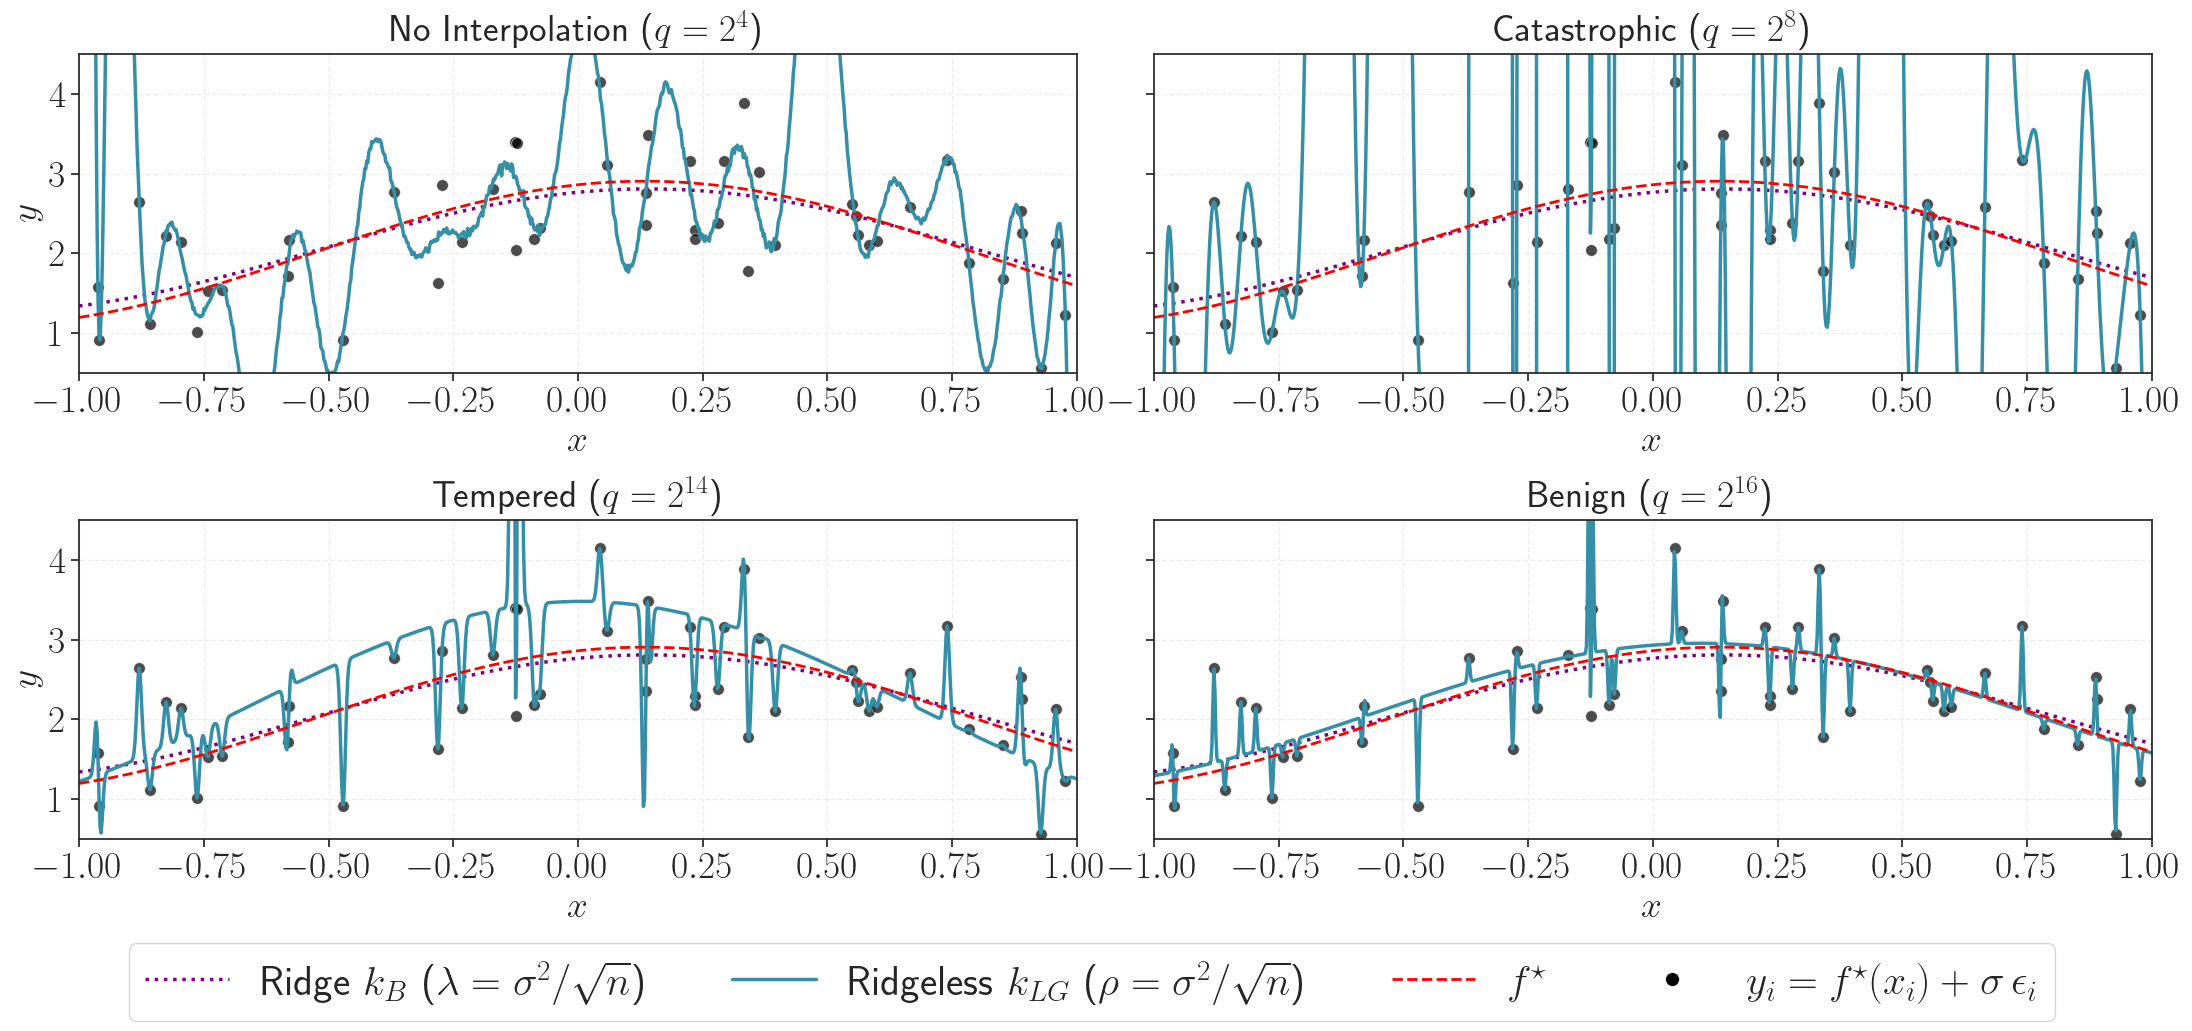

In [3]:
# ---------------------============
# Problem setup
# ---------------------============
n_train, d = 50, 1
sigma = np.sqrt(0.5)
sigma2 = sigma**2
eps = 1e-14
# Kernel parameters
c = 3*np.pi/4
q = 1

qpow = [4, 8, 14, 16]
q_list = [int(2**p) for p in qpow]

# Domain
L = 1
xlow, xhigh = -L, L

# fix randomness
np.random.seed(0)

# ---------------------============
# Target function 
# ---------------------============

n_z = 5
Z = np.random.uniform(xlow, xhigh, (n_z, d))

def fstar(X):
    K = local_kernel(X, Z, c) # local kernel is defined in kernels_utilsfinal.py
    return 2 * X.shape[-1] * np.mean(K, axis=1) + 1

# ---------------------============
# Training data
# ---------------------============

X_train = np.random.uniform(xlow, xhigh, (n_train, d))
y_train = fstar(X_train) + np.random.randn(n_train) * sigma

rho = sigma2 / np.sqrt(n_train)



# ---------------------============
# Fit models 
# ---------------------============

models = {}

# ---- base kernel Ridge ----
K_train = local_kernel(X_train, X_train, c)
alpha_ridge = compute_alphafig1(K_train, y_train, rho=rho)

models["ridge"] = {
    "alpha": alpha_ridge,
    "kernel": lambda X1, X2: local_kernel(X1, X2, c)
}



# ---- Spiky-Smooth (Local-Global) ----
for q in q_list:
    K_lg = local_global_kernel(K_train, rho, q)
    if q <=2**5:
        alpha_lg = compute_alphafig1(K_lg, y_train, rho=0,eps=eps)#eps
    else:
        alpha_lg = compute_alphafig1(K_lg, y_train, rho=0,eps=0)

    models[f"q_{q}"] = {
        "alpha": alpha_lg,
        "kernel": lambda X1, X2, q=q: 
            local_global_kernel(
                local_kernel(X1, X2, c),
                rho,
                q
            )
    }



# ---------------------============
# Test 
# ---------------------============

n_test = 1000
X_test = np.linspace(xlow, xhigh, n_test).reshape(-1, 1)

# ---------------------============
# Plot
# ---------------------============

sns.set(style='ticks')
colors = sns.color_palette("mako", 6)

fontsize = 27
fontsize_title = 27

fig, axs = plt.subplots(2, 2, figsize=(22, 10), sharey=True)
axs = axs.flatten()

titles = {
    0: rf"No Interpolation ($q=2^{{{qpow[0]}}}$)",
    1: rf"Catastrophic ($q=2^{{{qpow[1]}}}$)",
    2: rf"Tempered ($q=2^{{{qpow[2]}}}$)",
    3: rf"Benign ($q=2^{{{qpow[3]}}}$)"
}

for i, q in enumerate(q_list):

    # Ridge prediction
    K_test_ridge = models["ridge"]["kernel"](X_test, X_train)
    y_ridge = compute_predictions(K_test_ridge, models["ridge"]["alpha"])

    # LG prediction
    K_test_lg = models[f"q_{q}"]["kernel"](X_test, X_train)
    y_lg = compute_predictions(K_test_lg, models[f"q_{q}"]["alpha"])

    axs[i].plot(X_test, y_ridge,
                color='purple', linestyle=":", linewidth=2.5)

    axs[i].plot(X_test, y_lg,
                color=colors[3], linestyle="-", linewidth=2.5)

    axs[i].plot(X_test, fstar(X_test),
                color="red", linestyle="--", linewidth=2)

    axs[i].scatter(X_train, y_train,
                   color="black", s=70, alpha=0.7,
                   edgecolor='white', linewidth=0.5)

    axs[i].set_title(titles[i], fontsize=fontsize_title, pad=10)
    axs[i].set_xlabel("$x$", fontsize=fontsize_title)

    if i % 2 == 0:
        axs[i].set_ylabel("$y$", fontsize=fontsize)

    axs[i].tick_params(axis='both', which='major', labelsize=fontsize)
    axs[i].grid(True, alpha=0.3, linestyle='--')
    axs[i].set_ylim(0.5, 4.5)
    axs[i].set_xlim(xlow, xhigh)

# Legend
legend_labels = [
    "Ridge $k_B$ ($\\lambda=\\sigma^2/\\sqrt{n}$)",
    "Ridgeless $k_{LG}$ ($\\rho=\\sigma^2/\\sqrt{n}$)",
    r"$f^\star$",
    r"$y_i= f^\star(x_i) + \sigma\,\epsilon_i$"
]

handles = [
    plt.Line2D([0], [0], color='purple', linestyle=":", linewidth=2.5),
    plt.Line2D([0], [0], color=colors[3], linestyle="-", linewidth=2.5),
    plt.Line2D([0], [0], color="red", linestyle="--", linewidth=2),
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='black', markersize=10,
               linestyle='', markeredgecolor='white',
               markeredgewidth=0.5)
]

fig.legend(handles, legend_labels,
           loc='lower center',
           ncol=4,
           fontsize=30,
           frameon=True,
           bbox_to_anchor=(0.5, -0.05))

plt.tight_layout(rect=[0, 0.05, 1, 1])

#plt.savefig("overfitting_phase_diagram.png", dpi=300, bbox_inches="tight") # png
plt.savefig("overfitting_phase_diagram.pdf", dpi=300, bbox_inches="tight") # pdf

plt.show()

# B. experiment higher dimension

- target : $ f^\star(x)=\sum_{j=1}^{50} \alpha_j\, k^\star(x,z_j)-\mathbb{E}_{x'}\!\left[\sum_{j=1}^{50} \alpha_j\, k^\star(x',z_j)\right]$, $z_j \overset{\mathrm{i.i.d.}}{\sim} \mathcal{U}([-1,1]^d)$
- data: $n=500$, $d=7$ , $x_i \overset{\mathrm{i.i.d.}}{\sim} \mathcal{U}([-1,1]^d)$, $n_{test}=2000$
- kernel: $c=\frac{1}{\sqrt{d}}$ ,$\rho = \frac{\sigma^2}{\sqrt{n}}$,  $q = 2^p$ for $p\in\{2,4,6,8\}$

$\alpha_j$ are i.i.d. Gaussian coefficients rescaled so that $\mathbb{E}_x[f^\star(x)] = 0,$ $\mathrm{Var}(f_2^\star(x)) = 1,$ under $x \sim \mathcal{U}([-1,1]^d)$.

$k^\star = k_c + \rho^\star k_c^{q^\star}$ 

In [4]:
def run_experimentB(
    d=7,
    n_train=400,
    n_test=2000,
    n_splits=10,
    q_values=None,
    q_powers=None,
    c=None,
    L=1,
    sigma_frac=np.sqrt(0.5),
    target_std=1,
    nz=50,
    rhostar=0,
    qstar=1,
    reg=None,
    seed=1,              
):


    master_rng = np.random.default_rng(seed)

    if c is None:
        c = 1 / np.sqrt(d)

    if q_values is None:
        if q_powers is None:
            q_powers = [2,3,4,5,6,7,8]
        q_values = [2**p for p in q_powers]

    sigma = sigma_frac * target_std
    sigma2 = sigma**2

    xlow, xhigh = -L, L

    # ---------------------------------
    # fix target in all experiment ( change seed to change target function ) 
    # ---------------------------------
    teacher_seed = master_rng.integers(10**9)

    true_f = target_lgkfct(
    d=d,
    c=c,
    L=L,
    rho=rhostar,
    q=qstar,
    nz=nz,
    target_std=target_std,
    coef_seed=teacher_seed
    )
    results = []

    # ---------------------------------
    # Main loop
    # ---------------------------------
    for split in range(n_splits):

        # independent RNG per split
        split_seed = master_rng.integers(10**9)
        rng = np.random.default_rng(split_seed)

        # ---- Data ----
        X_train = rng.uniform(xlow, xhigh, (n_train, d))
        y_train = true_f(X_train) + rng.normal(size=n_train) * sigma

        X_test = rng.uniform(xlow, xhigh, (n_test, d))
        y_test = true_f(X_test) + rng.normal(size=n_test) * sigma

        # ---- Regularization ----
        reg_value = reg if reg is not None else (1+sigma)/np.sqrt(n_train)

        # ---- Precompute local kernel ----
        K_train_local = local_kernel(X_train, X_train, c)

        models = {}

        # Ridge
        alpha_ridge = compute_alpha(K_train_local, y_train, rho=reg_value)
        models["loc-$\\rho$"] = {
            "alpha": alpha_ridge,
            "kernel": lambda X1, X2: local_kernel(X1, X2, c)
        }

        # Ridgeless
        alpha_local0 = compute_alpha(K_train_local, y_train, rho=0)
        models["loc-$0$"] = {
            "alpha": alpha_local0,
            "kernel": lambda X1, X2: local_kernel(X1, X2, c)
        }

        # Local-global
        for q in q_values:

            K_train_lg = local_global_kernel(K_train_local, reg_value, q)
            alpha_lg = compute_alpha(K_train_lg, y_train, rho=0)

            models[f"lg-q:{q}"] = {
                "alpha": alpha_lg,
                "kernel": lambda X1, X2, q=q:
                    local_global_kernel(
                        local_kernel(X1, X2, c),
                        reg_value,
                        q
                    )
            }

        # ---- Evaluation ----
        for name, model in models.items():

            Ktr = model["kernel"](X_train, X_train)
            Kte = model["kernel"](X_test, X_train)

            y_train_pred = compute_predictions(Ktr, model["alpha"])
            y_test_pred  = compute_predictions(Kte, model["alpha"])

            results.append({
                "split": split,
                "model": name,
                "train_mse": compute_mse(y_train_pred, y_train),
                "test_mse": compute_mse(y_test_pred, y_test)
            })

    df_results = pd.DataFrame(results)

    df_summary = (
        df_results
        .groupby("model")
        .agg(
            train_mse_mean=("train_mse", "mean"),
            train_mse_std=("train_mse", "std"),
            test_mse_mean=("test_mse", "mean"),
            test_mse_std=("test_mse", "std")
        )
        .reset_index()
    )

    return df_results, df_summary, sigma2

In [5]:
def plot_synthetic_experiment(
    df_summary,
    sigma2,
    save_path=None,
    dpi=300,
    plot_sigma = True,
    title_fontsize=32,
    label_fontsize=26,
    tick_fontsize=22,
    figsize=(14, 4)    
):
    """
    Plot synthetic experiment results
    (two subplots: train / test).

    Order:
        1) local ridge
        2) local ridgeless
        3) local-global increasing q

    Custom labels:
        local ridge      ->  lambda=rho
        local ridgeless  ->  lambda=0
        local-global     ->  q=2^p
    """

    import numpy as np
    import matplotlib.pyplot as plt

    models = df_summary["model"].tolist()

    # Identify models
    locrho = [m for m in models if "loc-$\\rho$" in m]
    loc0   = [m for m in models if "loc-$0$" in m]
    lg     = [m for m in models if "lg-q" in m]

    # Sort LG by increasing q
    lg_sorted = sorted(lg, key=lambda x: int(x.split(":")[1]))

    # Final order
    ordered_models = locrho + loc0 + lg_sorted

    df_ordered = (
        df_summary
        .set_index("model")
        .loc[ordered_models]
        .reset_index()
    )

    # Extract metrics
    train_mean = df_ordered["train_mse_mean"].values
    train_std  = df_ordered["train_mse_std"].values
    test_mean  = df_ordered["test_mse_mean"].values
    test_std   = df_ordered["test_mse_std"].values

    # ------------------------
    # Build labels
    # ------------------------
    pretty_labels = []

    for m in ordered_models:

        if "loc-$\\rho$" in m:
            pretty_labels.append(r"$\lambda=\rho$")

        elif "loc-$0$" in m:
            pretty_labels.append(r"$\lambda=0$")

        elif "lg-q" in m:
            qval = int(m.split(":")[1])
            p = int(np.log2(qval))
            pretty_labels.append(rf"$q=2^{{{p}}}$")

    x = np.arange(len(pretty_labels))

    # ------------------------
    # Create figure
    # ------------------------
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=False)

    # ---- Train ----
    axes[0].bar(x, train_mean, yerr=train_std,
                capsize=4, color="orange")
    axes[0].set_yscale("log")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(pretty_labels,
                            rotation=45,
                            ha="center",
                            fontsize=tick_fontsize)
    axes[0].tick_params(axis='y', labelsize=label_fontsize)
    axes[0].set_ylabel(r"MSE (log scale)", fontsize=label_fontsize)
    axes[0].set_title("Train", fontsize=title_fontsize)

    # ---- Test ----
    axes[1].bar(x, test_mean, yerr=test_std,
                capsize=4)
    axes[1].set_yscale("log")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(pretty_labels,
                            rotation=45,
                            ha="center",
                            fontsize=tick_fontsize)
    axes[1].tick_params(axis='y', labelsize=label_fontsize)
    axes[1].set_title("Test", fontsize=title_fontsize)
    if plot_sigma:
        axes[1].axhline(
            sigma2,
            color="red",
            linestyle="--",
            linewidth=3,
            label=r"$\sigma^2$"
        )
        axes[1].legend(fontsize=label_fontsize)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

## B.1.  first experiment: $f^\star \in \mathcal{H}_{k_c}$  

Here $\sigma^2=0.5$ and $q^\star = 0$  ($k^\star = k_c $) 

In [6]:
n_splits = 10
n_train, d = 500, 7
sigma_frac = np.sqrt(0.5)
target_std = 1
sigma = sigma_frac * target_std
sigma2 = sigma**2
c = 1/np.sqrt(d)
qpow = [2,4,6,8]
qsp_list = [int(2**p) for p in qpow]
rho = sigma2/np.sqrt(n_train)
xlow, xhigh = -1, 1
L = 1

df_resultsd7n500, df_summaryd7n500, sigma2 =run_experimentB(
    d=d,
    n_train=n_train,
    n_test=2000,
    n_splits=n_splits,
    q_values=None,
    q_powers=qpow,
    c=c,
    L=L,
    sigma_frac=sigma_frac,
    target_std=target_std,
    nz=50,
    rhostar=0,
    qstar=1,
    reg=rho,
    seed=1)

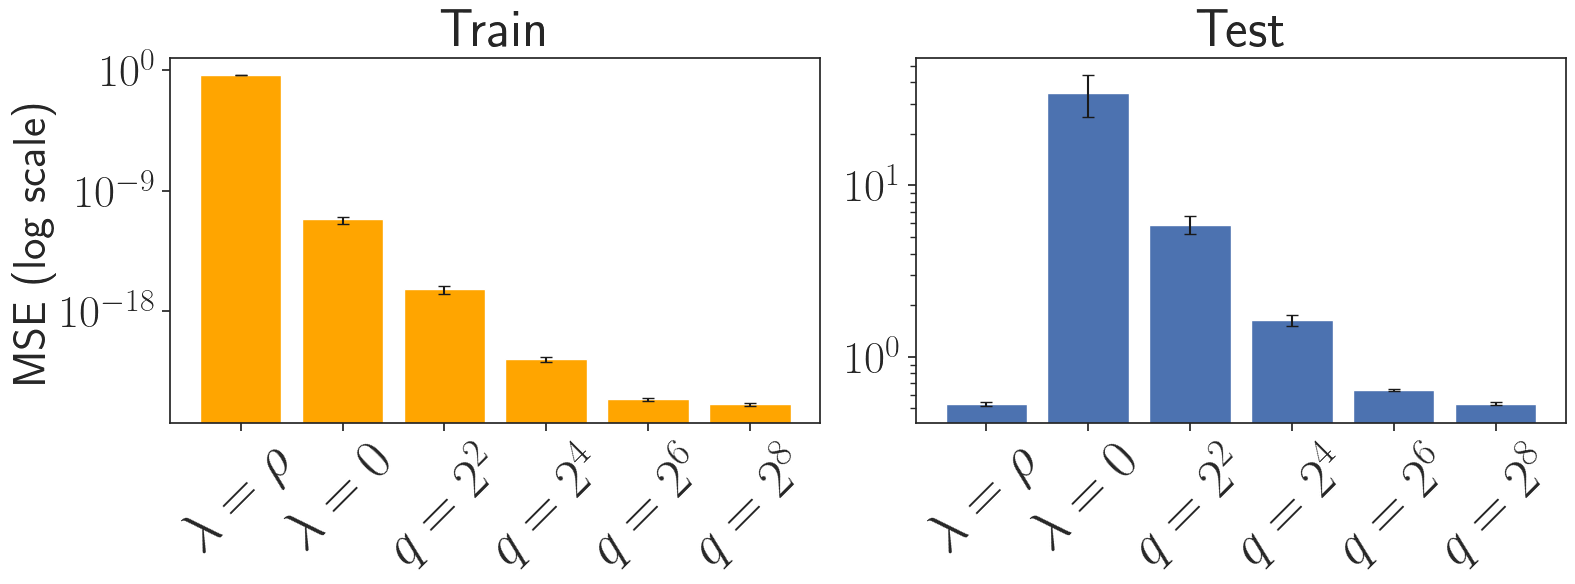

In [7]:
title_fontsize=32+7
label_fontsize=26+7
tick_fontsize=35+5
figsize=(16, 6)    

plot_synthetic_experiment(
    df_summaryd7n500,
    sigma2=sigma2,
    save_path="synthetic_d7n500in.pdf",
    title_fontsize=title_fontsize,
    plot_sigma=False,
    label_fontsize=label_fontsize,
    tick_fontsize=tick_fontsize,
    figsize=figsize    
)


## B.2.  second experiment: $f^\star \not \in \mathcal{H}_{k_c}$ but   $f^\star \in \mathcal{H}_{k_{LG}}$ (for  $q\ge q^\star$, $\rho \neq 0$)

Here $\sigma^2=7 \times 10^{-3}$ and $q^\star = 2^3, \rho^\star=5$  ($k^\star = k_c + 5k_c^8 $) 

In [8]:
n_splits = 10
n_train, d = 500, 7
sigma_frac = np.sqrt(7*10**(-3))#np.sqrt(0.5)
target_std = 1
sigma = sigma_frac * target_std
sigma2 = sigma**2
c = 1/np.sqrt(d)
qpow = [2,4,6,8]
q_list = [int(2**p) for p in qpow]


xlow, xhigh = -1, 1
L = 1
rhostar = 5
qstar = 8
rho =  sigma2/np.sqrt(n_train) 

df_resultsd7n500out, df_summaryd7n500out, sigma2 = run_experimentB(
    d=d,
    n_train=n_train,
    n_test=2000,
    n_splits=n_splits,
    q_values=None,
    q_powers=qpow,
    rhostar=rhostar,
    qstar=qstar,
    c=c,
    L=L,
    sigma_frac=sigma_frac,
    target_std=target_std,
)

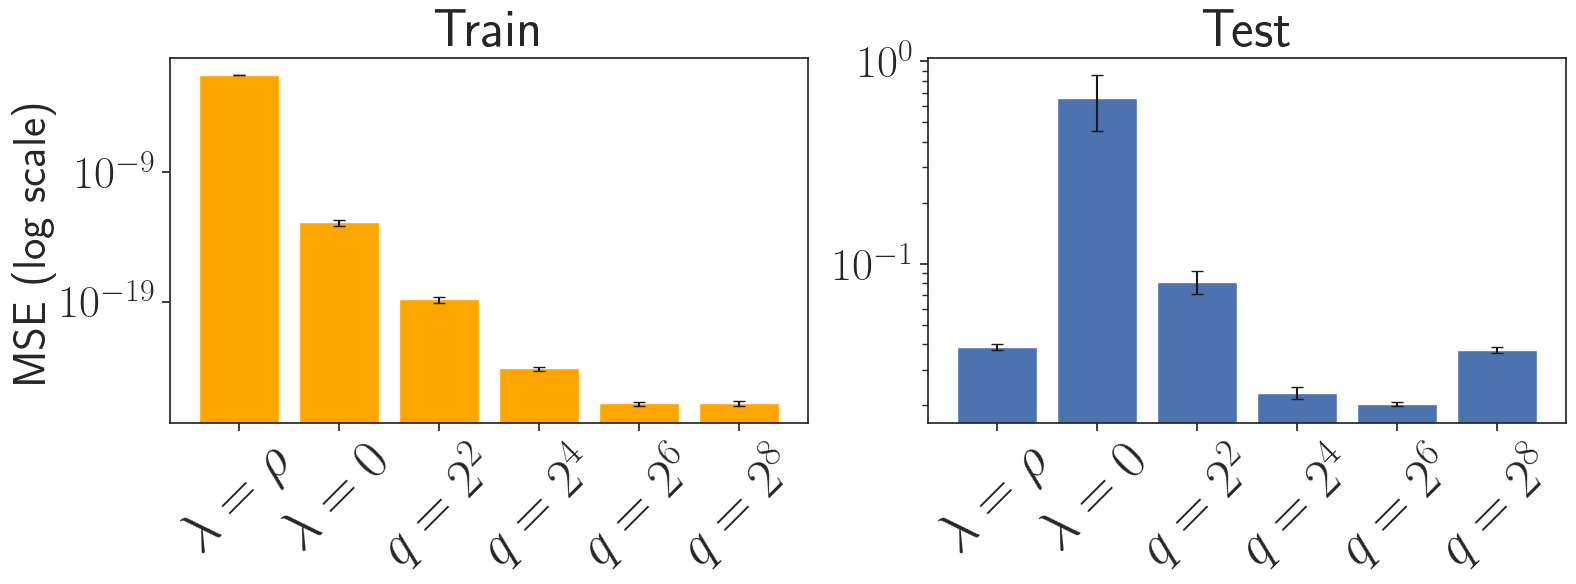

In [9]:
sigma_frac = np.sqrt(7*10**(-3))#np.sqrt(0.5)
target_std = 1
sigma = sigma_frac * target_std
sigma2 = sigma**2

plot_synthetic_experiment(
    df_summary=df_summaryd7n500out,
    sigma2=sigma2,
    save_path="synthetic_d7n500out.pdf",
    plot_sigma=False,
    title_fontsize=title_fontsize,
    label_fontsize=label_fontsize,
    tick_fontsize=tick_fontsize,
    figsize=figsize    
)


# C. consistency

 target : $ f^\star(x)=\sum_{j=1}^{50} \alpha_j\, k_c(x,z_j)-\mathbb{E}_{x'}\!\left[\sum_{j=1}^{50} \alpha_j\, k_c(x',z_j)\right]$, $z_j \overset{\mathrm{i.i.d.}}{\sim} \mathcal{U}([-1,1]^d)$
- data: $n \in \{25,50,100,150,\dots,500\}$, $d=7$ , $x_i \overset{\mathrm{i.i.d.}}{\sim} \mathcal{U}([-1,1]^d)$,$n_{test = 2000}$
- kernel: $c=\frac{1}{\sqrt{d}}$ ,$\rho = \frac{\sigma^2}{\sqrt{n}}$,  $q_n =  \left\lceil 10 \log(n)\, n^{6/d} \right\rceil$

In [10]:
def run_regressionsC(
    target,
    q_seq,
    d=3,
    n_val=[10, 20, 50, 100, 250, 500],
    n_splits=5,
    sigma_frac=0.1,
    n_test=2000,
    c=None,
    seed=123,
    L=None,
    rho1 = 1
):

    rng = np.random.default_rng(seed)

    def add_noise(y, sigma):
        return y + sigma * rng.standard_normal(size=y.shape)

    df_results = []

    qn_names = list(q_seq.keys())
    kernel_models = ["local_ridge", "local_ridgeless"] + qn_names

    # Bandwidth
    if c is None:
        c = bandwidth(d=d)

    if L is None:
        L = domain_half_width(c)

    sample = lambda n: rng.uniform(-L, L, size=(n, d))

    for model_name in kernel_models:

        for n in n_val:

            rho = rho1 / np.sqrt(n)

            # determine q_n
            q = 0
            if model_name not in ["local_ridge", "local_ridgeless"]:
                q = q_seq[model_name](n, d)

            for i_split in range(n_splits):

                # ----------------------
                # Data generation
                # ----------------------
                X_train = sample(n)
                X_test = sample(n_test)

                fx_train = target(X_train)
                fx_test = target(X_test)

                sigma = np.std(fx_test) * sigma_frac

                y_train = add_noise(fx_train, sigma)
                y_test = add_noise(fx_test, sigma)

                # ----------------------
                # Kernel computation
                # ----------------------
                K_train = local_kernel(X_train, X_train, c)
                K_test = local_kernel(X_test, X_train, c)

                if model_name not in ["local_ridge", "local_ridgeless"]:
                    K_train = local_global_kernel(K_train, rho, q)
                    K_test = local_global_kernel(K_test, rho, q)

                # ----------------------
                # Regression
                # ----------------------
                lamb = 0.0
                if model_name == "local_ridge":
                    lamb = rho

                alpha = compute_alpha(K_train, y_train, lamb)

                y_train_pred = compute_predictions(K_train, alpha)
                y_test_pred = compute_predictions(K_test, alpha)

                mse_train = compute_mse(y_train_pred, y_train)
                mse_test = compute_mse(y_test_pred, y_test)

                df_results.append({
                    "i_split": i_split,
                    "model": model_name,
                    "n_train": n,
                    "q_n": q,
                    "mse_train": mse_train,
                    "mse_test": mse_test,
                })

    return pd.DataFrame(df_results)

In [11]:
def plot_experimentsC(
    df,
    save_path=None,
    sigma=0.1,
    main_model=None,
    plot_bayes_risk=True,
    epsilon_ylim=0.05,      # y_min(left) = log10(sigma^2) - epsilon_ylim
    band_alpha=0.22,
    eps=1e-12,
    figsize=(16, 6),
    fontsize=22,
    fontsize_leg=18,
    fontsize_title=24,
    main_color="teal",
    base_color="purple",
    noise_color="red",
    main_lw=3.2,
    base_lw=2.6,
    noise_lw=3.0,
    low=-0.07,
    xtick_step=100,       
    xtick_start=None,      
):


    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D

    lrless = "local_ridgeless"

    # -----------------------------
    # Aggregate results
    # -----------------------------
    grouped = df.groupby(["model", "n_train", "q_n"])
    df_toplot = grouped.agg(
        mean_mse_test=("mse_test", "mean"),
        std_mse_test=("mse_test", "std"),
        n_rep=("mse_test", "count"),
    ).reset_index()

    # pick main model (fallback: first non-baseline sorted)
    models = df_toplot["model"].drop_duplicates().tolist()
    qn_models = sorted([m for m in models if m != lrless])

    if main_model is None:
        main_model = qn_models[0] if len(qn_models) else None

    if (main_model is None) or (main_model not in df_toplot["model"].unique()):
        raise ValueError("main_model not found in df['model'].")

    # -----------------------------
    # Helpers
    # -----------------------------
    def _log_band(mean_vals, std_vals):
        mean_vals = np.asarray(mean_vals, dtype=float)
        std_vals = np.asarray(std_vals, dtype=float)
        y = np.log10(np.maximum(mean_vals, eps))
        yhi = np.log10(np.maximum(mean_vals + std_vals, eps))
        ylo = np.log10(np.maximum(mean_vals - std_vals, eps))
        return y, ylo, yhi

    bayes_y = np.log10(max(sigma**2, eps)) if plot_bayes_risk else None

    # -----------------------------
    # Figure
    # -----------------------------
    fig, (axL, axR) = plt.subplots(1, 2, figsize=figsize, sharex=True)

    # ===== Left: main curve =====
    df_main = df_toplot[df_toplot.model == main_model].sort_values("n_train")
    x = df_main["n_train"].to_numpy()
    y, ylo, yhi = _log_band(df_main["mean_mse_test"], df_main["std_mse_test"])

    axL.plot(x, y, "-o", color=main_color, lw=main_lw, ms=5, zorder=3)
    axL.fill_between(x, ylo, yhi, color=main_color, alpha=band_alpha, zorder=2)

    if plot_bayes_risk:
        axL.axhline(bayes_y, color=noise_color, ls=":", lw=noise_lw, zorder=1)
        # enforce left y-min = noise floor - epsilon_ylim
        axL.set_ylim(bayes_y - epsilon_ylim, max(np.max(yhi), bayes_y) + 0.02)

    # ===== Right: baseline diverges =====
    df_base = df_toplot[df_toplot.model == lrless].sort_values("n_train")
    if not df_base.empty:
        xb = df_base["n_train"].to_numpy()
        yb, yblo, ybhi = _log_band(df_base["mean_mse_test"], df_base["std_mse_test"])

        axR.plot(xb, yb, "--o", color=base_color, lw=base_lw, ms=4, zorder=3)
        axR.fill_between(xb, yblo, ybhi, color=base_color, alpha=band_alpha, zorder=2)

    if plot_bayes_risk:
        axR.axhline(bayes_y, color=noise_color, ls=":", lw=noise_lw, zorder=1)

    # -----------------------------
    #  X ticks every xtick_step
    # -----------------------------
    all_n = df_toplot["n_train"].to_numpy()
    n_min, n_max = int(all_n.min()), int(all_n.max())

    if xtick_start is None:
        # smallest multiple of xtick_step >= n_min
        xtick_start = ((n_min + xtick_step - 1) // xtick_step) * xtick_step

    xticks = np.arange(xtick_start, n_max + 1, xtick_step)

    for ax in (axL, axR):
        ax.set_xticks(xticks)

    # -----------------------------
    # Styling
    # -----------------------------
    for ax in (axL, axR):
        ax.set_xlabel(r"Training size $n$", fontsize=fontsize)
        ax.tick_params(labelsize=fontsize)
        ax.grid(True, alpha=0.6, linestyle="--")

    axL.set_ylabel(r"$\log_{10}(\mathrm{Test\ MSE})$", fontsize=fontsize)

    axL.set_title("Consistent", fontsize=fontsize_title)
    axR.set_title("Inconsistent", fontsize=fontsize_title)

    # -----------------------------
    # Legend
    # -----------------------------
    handles = [
        Line2D([0], [0], color=main_color, lw=main_lw, marker="o", linestyle="-"),
        Line2D([0], [0], color=base_color, lw=base_lw, marker="o", linestyle="--"),
    ]
    labels = [
        main_model,
        r"$k_B\ (\lambda=0)$",
    ]
    if plot_bayes_risk:
        handles.append(Line2D([0], [0], color=noise_color, lw=noise_lw, linestyle=":"))
        labels.append(r"$\mathbb{E}[(f^*-y)^2]=\sigma^2$")

    fig.legend(
        handles, labels,
        loc="lower center",
        ncol=3,
        fontsize=fontsize_leg,
        frameon=True,
        bbox_to_anchor=(0.5, low),
    )

    plt.tight_layout(rect=[0, 0.10, 1, 1])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [12]:

# ------------------------
# q_n sequence
# ------------------------
def q_bo(n,d): return int(np.ceil(10*np.log(n) * n**(6/d)))
q_sequences = {
    r'$q_n = \lceil 10 \log (n) n^{\frac{6}{d}} \rceil$': q_bo
}

# ------------------------
# Target function
# ------------------------
d= 7 
c = bandwidth(d=d)  # kernel bandwidth given by Canatar for cosine squared kernel 
n_list =[25,50,100,150,200,250,300,350,400,450,500] #[50,100,150,200,250,300,350,400,450,500,550,600]#,650,700,750,800,850,900,950,1000]  

n_repeats = 10
sigma_frac = np.sqrt(0.5) 
target_std = 1  
sigma = sigma_frac*target_std
rho1 = sigma**2
L = 1

#take target  in local kernel RKHS
seed = 1 # fix the target
master_rng = np.random.default_rng(seed)
teacher_seed = master_rng.integers(10**9)

target_inlocal =  target_lgkfct(
    d=d,
    c=c,
    L=1,
    rho=0,
    q=1,
    nz=50,
    target_std=target_std,
    coef_seed=teacher_seed
    )


# ------------------------
# Run experiments
# ------------------------
df_inlocal = run_regressionsC(target=target_inlocal,d=d,q_seq = q_sequences,n_val = n_list,n_splits = n_repeats,sigma_frac=sigma_frac,rho1 = rho1,L=L)


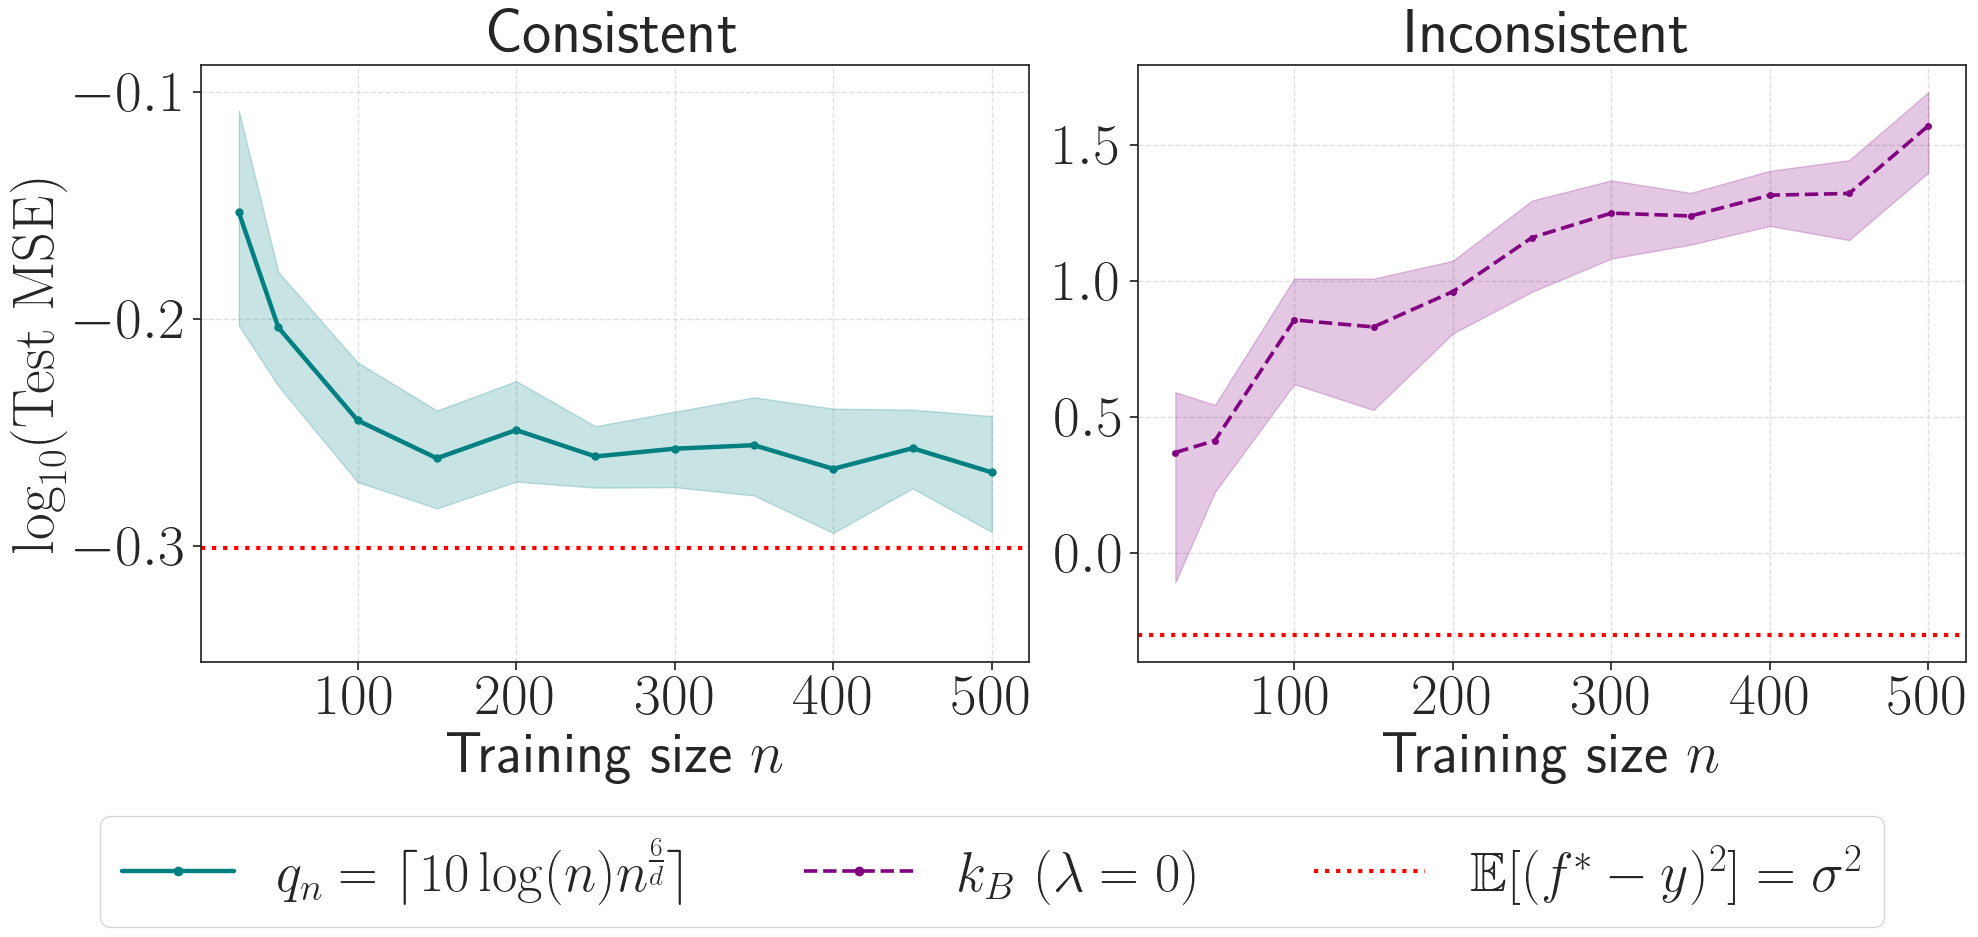

In [13]:
# ------------------------
# Plot
# ------------------------

figsize=(20, 9)
fontsize=22+20
fontsize_leg=20+20
fontsize_title=25+20
low = -0.07
plot_experimentsC(
    df=df_inlocal,
    save_path="qnbod7.pdf",
    sigma=sigma_frac * target_std,
    figsize=figsize,
    fontsize=fontsize,  
    fontsize_leg=fontsize_leg,
    fontsize_title=fontsize_title,
    low=low
)

# D. small example real data

We run real date experiment on airfoil and cal housing dataset  on $n_{ntrain}=500$ exemple.

In [14]:

def load_regression_dataset(dataset_name='cal_housing',
                            N_full=None,
                            random_state=0,
                            standardize=True):

    import numpy as np
    from sklearn.preprocessing import StandardScaler

    rng = np.random.RandomState(random_state)

    # ---------------------
    # Load dataset
    # ---------------------
    if dataset_name == 'cal_housing':
        from sklearn.datasets import fetch_california_housing
        data = fetch_california_housing()
        X, y = data.data, data.target

    elif dataset_name == 'airfoil':
        from sklearn.datasets import fetch_openml
        data = fetch_openml(data_id=1507, as_frame=False)
        X, y = data.data, data.target.astype(float)

    else:
        raise ValueError("dataset_name must be 'cal_housing' or 'airfoil'")

    # ---------------------
    # Optional subsampling if dataset too large
    # ---------------------
    if N_full is not None and N_full < len(X):
        idx = rng.choice(len(X), size=N_full, replace=False)
        X, y = X[idx], y[idx]

    # ---------------------
    # Remove NaNs
    # ---------------------
    mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X, y = X[mask], y[mask]

    # ---------------------
    # Standardize features
    # ---------------------
    if standardize:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    print(f"Loaded dataset '{dataset_name}' with N = {len(X)} samples (after Nan removing) and d = {X.shape[1]} features.")
    return X.astype(float), y.astype(float)

In [15]:
def tune_c_rho_global(
    X, y,
    n_train,
    n_tuning_splits,
    c_grid,
    rho_grid,
    random_state=0,
):
    """
    Tuning/learning (c, rho) for local ridge for the dataset (X,y) using n_train samples for training and n_tuning_splits random splits for tuning.
    Returns the best (c, rho) and a dictionary of average tuning losses for each pair. 
    """

    import numpy as np
    from sklearn.model_selection import train_test_split

    tuning_losses = {(c, rho): [] for c in c_grid for rho in rho_grid}

    for t in range(n_tuning_splits):

        Xtr, Xval, ytr, yval = train_test_split(
            X, y,
            train_size=n_train,
            random_state=random_state + 1000 * t,
            test_size=int(0.5*n_train),
        )

        for c in c_grid:

            Ktr = local_kernel(Xtr, Xtr, c)
            Kval = local_kernel(Xval, Xtr, c)

            for rho in rho_grid:

                alpha = compute_alpha(Ktr, ytr, rho)
                yval_pred = compute_predictions(Kval, alpha)
                loss = compute_mse(yval_pred, yval)

                tuning_losses[(c, rho)].append(loss)

    avg_losses = {
        (c, rho): np.mean(losses)
        for (c, rho), losses in tuning_losses.items()
    }

    c_star, rho_star = min(avg_losses, key=avg_losses.get)

    return c_star, rho_star, avg_losses

In [16]:
def run_experimentD_real_data(
    dataset_name="cal_housing",
    N_full=400,
    n_train=200,
    n_splits=5,
    n_tuning_splits=3,
    c_grid=None,
    rho_grid=None,
    q_list=(2, 4, 8, 16),
    random_state=0,
):
    """
    Two-stage experiment:
    1) global tuning of (c*, rho*)
    2) evaluation using fixed (c*, rho*)
    """

    import numpy as np
    from sklearn.model_selection import train_test_split

    if c_grid is None:
        c_grid = np.linspace(0.5, 3.0, 6)

    if rho_grid is None:
        rho_grid = np.logspace(-4, -1, 4)

    # ------------------
    # Load dataset
    # ------------------
    X, y = load_regression_dataset(
        dataset_name=dataset_name,
        N_full=N_full,
        random_state=random_state,
    )

    # ------------------
    # Hyperparameter tuning
    # ------------------
    c_star, rho_star, tuning_losses = tune_c_rho_global(
        X, y,
        n_train=n_train,
        n_tuning_splits=n_tuning_splits,
        c_grid=c_grid,
        rho_grid=rho_grid,
        random_state=random_state,
    )

    print(f"[TUNING] Selected c*={c_star}, rho*={rho_star},tuning_losses={tuning_losses}")

    results = []

    # ------------------
    # Evaluation
    # ------------------
    for split in range(n_splits):

        Xtr, Xte, ytr, yte = train_test_split(
            X, y,
            train_size=n_train,
            random_state=random_state + split,
        )

        # ---- Base local kernel ----
        Ktr = local_kernel(Xtr, Xtr, c_star)
        Kte = local_kernel(Xte, Xtr, c_star)

        # ---- Local ridgeless ----
        alpha = compute_alpha(Ktr, ytr, rho=0.0)
        results.append({
            "split": split,
            "model": "local_ridgeless",
            "q": 0,
            "mse_train": compute_mse(compute_predictions(Ktr, alpha), ytr),
            "mse_test": compute_mse(compute_predictions(Kte, alpha), yte),
        })

        # ---- Local ridge ----
        alpha = compute_alpha(Ktr, ytr, rho=rho_star)
        results.append({
            "split": split,
            "model": "local_ridge",
            "q": 0,
            "mse_train": compute_mse(compute_predictions(Ktr, alpha), ytr),
            "mse_test": compute_mse(compute_predictions(Kte, alpha), yte),
        })

        # ---- Local-global ridgeless ----
        for q in q_list:

            Ktr_lg = local_global_kernel(Ktr, rho_star, q)
            Kte_lg = local_global_kernel(Kte, rho_star, q)

            alpha = compute_alpha(Ktr_lg, ytr, rho=0.0)

            results.append({
                "split": split,
                "model": "local_global_ridgeless",
                "q": q,
                "mse_train": compute_mse(
                    compute_predictions(Ktr_lg, alpha), ytr
                ),
                "mse_test": compute_mse(
                    compute_predictions(Kte_lg, alpha), yte
                ),
            })

    return pd.DataFrame(results), {
        "c_star": c_star,
        "rho_star": rho_star
    }

In [17]:
def plot_experimentD(
    df,
    save_path=None,
    dpi=300,
    title_fontsize=32,
    label_fontsize=26,
    tick_fontsize=22,
    figsize=(14, 6),
    ytick_label_fontsize=None,
    test_decimal_ticks=True,   
    test_decimal_fmt="{y:.2f}",
):
    """
    Plot experiment results (real data version).
    Order:
        1) local ridge
        2) local ridgeless
        3) local-global increasing q

    test_decimal_ticks:
        - True  -> show test y ticks as decimals (0.04, 0.05, ...)
        - False -> show test y ticks in scientific log format (10^k)
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import (
        LogLocator,
        LogFormatterMathtext,
        FuncFormatter,
        NullFormatter,
    )

    # ----------------------------------
    # Aggregate over splits
    # ----------------------------------
    df_summary = (
        df.groupby(["model", "q"])
        .agg(
            train_mse_mean=("mse_train", "mean"),
            train_mse_std=("mse_train", "std"),
            test_mse_mean=("mse_test", "mean"),
            test_mse_std=("mse_test", "std"),
        )
        .reset_index()
    )

    # ----------------------------------
    # Identify models
    # ----------------------------------
    locrho = df_summary[df_summary["model"] == "local_ridge"]
    loc0   = df_summary[df_summary["model"] == "local_ridgeless"]
    lg     = df_summary[df_summary["model"] == "local_global_ridgeless"]

    lg_sorted = lg.sort_values("q")
    df_ordered = pd.concat([locrho, loc0, lg_sorted], axis=0)

    # ----------------------------------
    # Extract metrics
    # ----------------------------------
    train_mean = df_ordered["train_mse_mean"].values
    train_std  = df_ordered["train_mse_std"].values
    test_mean  = df_ordered["test_mse_mean"].values
    test_std   = df_ordered["test_mse_std"].values

    # ----------------------------------
    # Pretty labels
    # ----------------------------------
    pretty_labels = []
    for _, row in df_ordered.iterrows():
        if row["model"] == "local_ridge":
            pretty_labels.append(r"$\lambda=\rho$")
        elif row["model"] == "local_ridgeless":
            pretty_labels.append(r"$\lambda=0$")
        elif row["model"] == "local_global_ridgeless":
            qval = int(row["q"])
            log2q = np.log2(qval)
            if float(log2q).is_integer():
                pretty_labels.append(rf"$q=2^{{{int(log2q)}}}$")
            else:
                pretty_labels.append(rf"$q={qval}$")

    x = np.arange(len(pretty_labels))

    if ytick_label_fontsize is None:
        ytick_label_fontsize = tick_fontsize

    # ----------------------------------
    # Plot
    # ----------------------------------
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=False)

    # ---- Train ----
    axes[0].bar(x, train_mean, yerr=train_std, capsize=4, color="orange")
    axes[0].set_yscale("log")

    axes[0].yaxis.set_major_locator(LogLocator(base=10))
    axes[0].yaxis.set_major_formatter(LogFormatterMathtext())
    axes[0].yaxis.set_minor_formatter(NullFormatter())
    axes[0].tick_params(axis="y", labelsize=ytick_label_fontsize)

    axes[0].set_ylabel(r"MSE (log scale)", fontsize=label_fontsize)
    axes[0].set_title("Train", fontsize=title_fontsize)

    # ---- Test ----
    axes[1].bar(x, test_mean, yerr=test_std, capsize=4)
    axes[1].set_yscale("log")

    if test_decimal_ticks:
        # decimals: 0.04, 0.05, ..., 0.09 (works well when values are ~1e-2)
        axes[1].yaxis.set_major_locator(LogLocator(base=10, subs=(4, 5, 6, 7, 8, 9)))
        axes[1].yaxis.set_major_formatter(
            FuncFormatter(lambda y, _: test_decimal_fmt.format(y=y))
        )
        axes[1].yaxis.set_minor_formatter(NullFormatter())
    else:
        # classic scientific log ticks: 10^{-2}, 10^{-1}, ...
        axes[1].yaxis.set_major_locator(LogLocator(base=10))
        axes[1].yaxis.set_major_formatter(LogFormatterMathtext())
        axes[1].yaxis.set_minor_formatter(NullFormatter())

    axes[1].tick_params(axis="y", labelsize=ytick_label_fontsize)
    axes[1].set_title("Test", fontsize=title_fontsize)

    # ---- Force x ticks/labels on both axes  ----
    for ax in axes:
        ax.set_xlim(-0.5, len(x) - 0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(pretty_labels, rotation=90, ha="center", fontsize=tick_fontsize)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

In [18]:
def plot_experimentD_bestq(
    df,
    save_path=None,
    dpi=300,
    title_fontsize=32,
    label_fontsize=26,
    tick_fontsize=22,
    figsize=(14, 6),
    ytick_label_fontsize=None,
    test_decimal_ticks=True,       
    test_decimal_fmt="{y:.2f}",     
):
    """
    Plot:
        1) local ridge
        2) local ridgeless
        3) best local-global (lowest mean test MSE)

    Best q is selected using mean test MSE.

    test_decimal_ticks:
        - True  -> show test y ticks as decimals (0.04, 0.05, ...)
        - False -> show test y ticks in scientific log format (10^k)
    """

    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.ticker import (
        LogLocator,
        LogFormatterMathtext,
        FuncFormatter,
        NullFormatter,
    )

    # ----------------------------------
    # Aggregate over splits
    # ----------------------------------
    df_summary = (
        df.groupby(["model", "q"])
        .agg(
            train_mse_mean=("mse_train", "mean"),
            train_mse_std=("mse_train", "std"),
            test_mse_mean=("mse_test", "mean"),
            test_mse_std=("mse_test", "std"),
        )
        .reset_index()
    )

    # ----------------------------------
    # Extract models
    # ----------------------------------
    locrho = df_summary[df_summary["model"] == "local_ridge"]
    loc0   = df_summary[df_summary["model"] == "local_ridgeless"]
    lg     = df_summary[df_summary["model"] == "local_global_ridgeless"]

    # ----------------------------------
    # Select best q (lowest mean test MSE)
    # ----------------------------------
    best_lg = lg.loc[lg["test_mse_mean"].idxmin()]
    best_q = int(best_lg["q"])

    # ----------------------------------
    # Concatenate in order
    # ----------------------------------
    df_ordered = pd.concat([locrho, loc0, best_lg.to_frame().T], axis=0)

    train_mean = df_ordered["train_mse_mean"].values
    train_std  = df_ordered["train_mse_std"].values
    test_mean  = df_ordered["test_mse_mean"].values
    test_std   = df_ordered["test_mse_std"].values

    # ----------------------------------
    # Labels
    # ----------------------------------
    log2q = np.log2(best_q)
    if float(log2q).is_integer():
        best_label = rf"$q=2^{{{int(log2q)}}}$"
    else:
        best_label = rf"$q={best_q}$"

    pretty_labels = [r"$\lambda=\rho$", r"$\lambda=0$", best_label]
    x = np.arange(3)

    if ytick_label_fontsize is None:
        ytick_label_fontsize = tick_fontsize

    # ----------------------------------
    # Plot
    # ----------------------------------
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=False)

    # -----------------
    # Train (log, scientific)
    # -----------------
    axes[0].bar(x, train_mean, yerr=train_std, capsize=4, color="orange")
    axes[0].set_yscale("log")
    axes[0].yaxis.set_major_locator(LogLocator(base=10))
    axes[0].yaxis.set_major_formatter(LogFormatterMathtext())
    axes[0].yaxis.set_minor_formatter(NullFormatter())
    axes[0].tick_params(axis="y", labelsize=ytick_label_fontsize)

    axes[0].set_ylabel("MSE (log scale)", fontsize=label_fontsize)
    axes[0].set_title("Train", fontsize=title_fontsize)

    # -----------------
    # Test (log, decimals OR scientific)
    # -----------------
    axes[1].bar(x, test_mean, yerr=test_std, capsize=4)
    axes[1].set_yscale("log")

    if test_decimal_ticks:
        # show ticks like 0.04, 0.05, ..., 0.09 (nice when values are ~1e-2)
        axes[1].yaxis.set_major_locator(LogLocator(base=10, subs=(4, 5, 6, 7, 8, 9)))
        axes[1].yaxis.set_major_formatter(
            FuncFormatter(lambda y, _: test_decimal_fmt.format(y=y))
        )
        axes[1].yaxis.set_minor_formatter(NullFormatter())
    else:
        # classic scientific log ticks
        axes[1].yaxis.set_major_locator(LogLocator(base=10))
        axes[1].yaxis.set_major_formatter(LogFormatterMathtext())
        axes[1].yaxis.set_minor_formatter(NullFormatter())

    axes[1].tick_params(axis="y", labelsize=ytick_label_fontsize)
    axes[1].set_title("Test", fontsize=title_fontsize)

    # -----------------
    # Force x ticks/labels (robust)
    # -----------------
    for ax in axes:
        ax.set_xlim(-0.5, len(x) - 0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(pretty_labels, fontsize=tick_fontsize)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()
    print(f"Best q selected: {best_q}")

# D.1 Airfoil dataset

In [19]:


# -----------------
# parameters
# -----------------
dataset_name = 'airfoil'
N_full = None # select all data (after NaN removal) N_full = 20640 for cal_housing, N_full = 7400 for airfoil
n_train = 500 # n_test = N_full - n_train
c_grid = np.linspace(10**(-4),1,10)
rho_grid = np.linspace(10**(-3),2,10)
q_list = [int(2**p) for p in range(1, 11)]
n_tune = 5 # number of splits for tuning (train/val splits) , n_val = 0.5*n_train
n_splits = 10 # number of splits for final evaluation (train/test splits)
# -----------------
# run experiment
# -----------------
df_results_airfoil500, hyperparams_airfoil500 = run_experimentD_real_data(
    dataset_name=dataset_name,
    N_full=N_full,
    n_train=n_train,
    n_splits=n_splits,
    n_tuning_splits=n_tune,
    c_grid=c_grid,
    rho_grid=rho_grid,
    q_list=q_list,
    random_state=0,
)


Loaded dataset 'airfoil' with N = 7400 samples (after Nan removing) and d = 20 features.
[TUNING] Selected c*=0.2223, rho*=0.22311111111111112,tuning_losses={(0.0001, 0.001): 0.2463888486910401, (0.0001, 0.22311111111111112): 0.25056789311789773, (0.0001, 0.44522222222222224): 0.25057496515557703, (0.0001, 0.6673333333333333): 0.25057657188962873, (0.0001, 0.8894444444444445): 0.2505774697151284, (0.0001, 1.1115555555555554): 0.25057861151145744, (0.0001, 1.3336666666666666): 0.25058031382963236, (0.0001, 1.5557777777777777): 0.2505827111202249, (0.0001, 1.7778888888888889): 0.2505858694849773, (0.0001, 2.0): 0.25058982463251833, (0.11120000000000001, 0.001): 0.05395193032105017, (0.11120000000000001, 0.22311111111111112): 0.04704314724528824, (0.11120000000000001, 0.44522222222222224): 0.047321740034361216, (0.11120000000000001, 0.6673333333333333): 0.04766694163725914, (0.11120000000000001, 0.8894444444444445): 0.048117649430603274, (0.11120000000000001, 1.1115555555555554): 0.048671

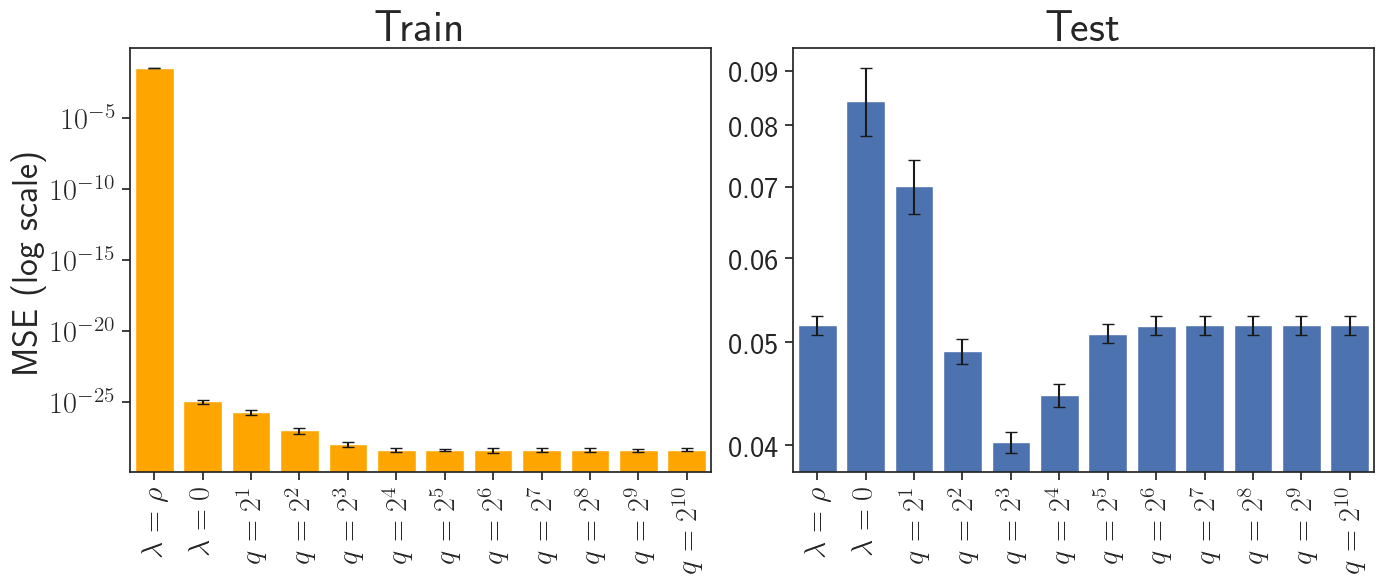

In [20]:
plot_experimentD(
    df_results_airfoil500,
    save_path="airfoiln500.pdf"
)

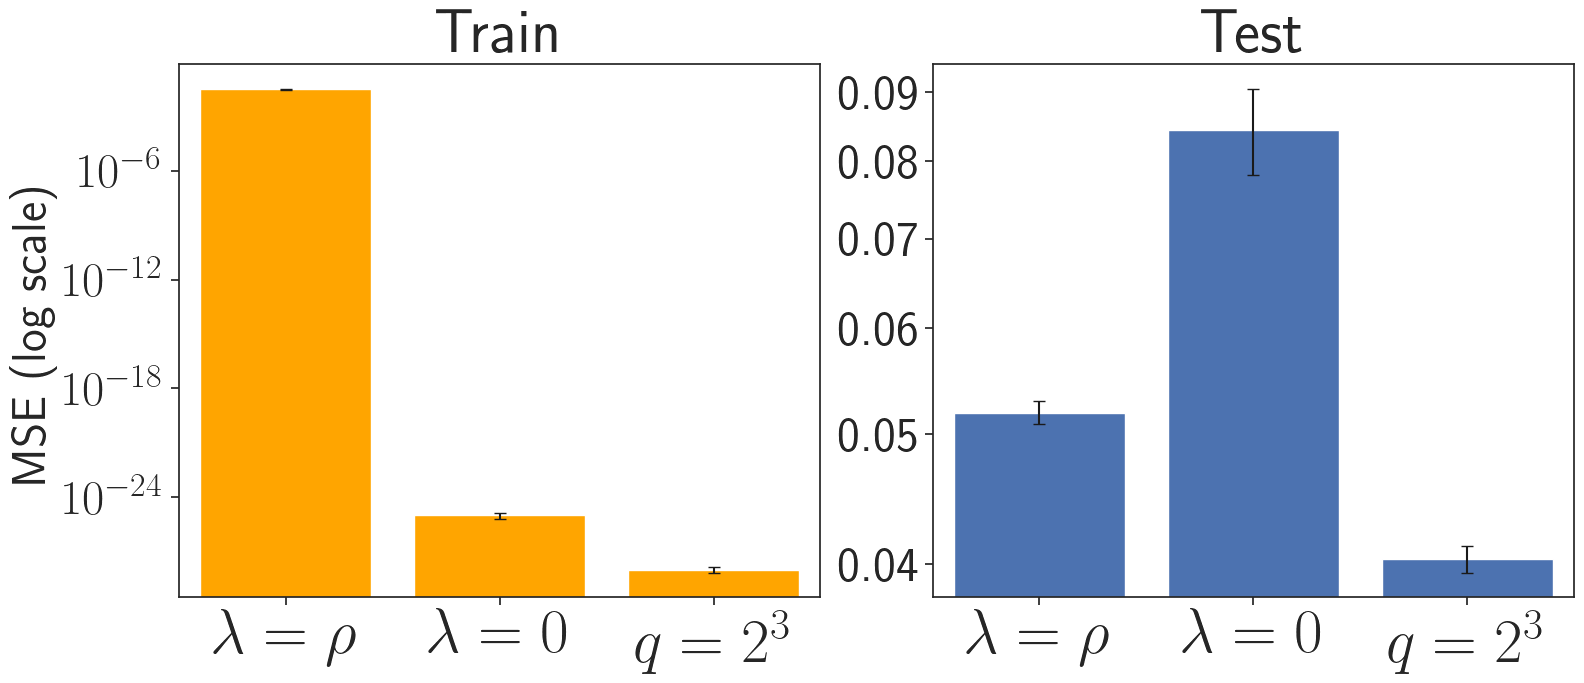

Best q selected: 8


In [21]:
title_fontsize=40+5
label_fontsize=30 +5
tick_fontsize=40+5
figsize=(16, 7)
ytick_label_fontsize=30+5
plot_experimentD_bestq(
    df_results_airfoil500,
    save_path="airfoiln500_bestq.pdf",
    title_fontsize=title_fontsize,
    label_fontsize=label_fontsize,
    tick_fontsize=tick_fontsize,
    figsize=figsize,
    ytick_label_fontsize=ytick_label_fontsize,

)

## D.2 California Housing

In [22]:


# -----------------
# parameters
# -----------------
dataset_name = 'cal_housing'
N_full = None # select all data (after NaN removal) N_full = 20640 for cal_housing, N_full = 7400 for airfoil
n_train = 500 # n_test = N_full - n_train
c_grid = np.linspace(10**(-4),1,10)
rho_grid = np.linspace(10**(-3),2,10)
q_list = [int(2**p) for p in range(1, 11)]
n_tune = 5 # number of splits for tuning (train/val splits) , n_val = 0.5*n_train
n_splits = 10 # number of splits for final evaluation (train/test splits)
# -----------------
# run experiment
# -----------------
df_results_calhousing500, hyperparams_calhousing500 = run_experimentD_real_data(
    dataset_name=dataset_name,
    N_full=N_full,
    n_train=n_train,
    n_splits=n_splits,
    n_tuning_splits=n_tune,
    c_grid=c_grid,
    rho_grid=rho_grid,
    q_list=q_list,
    random_state=0,
)


Loaded dataset 'cal_housing' with N = 20640 samples (after Nan removing) and d = 8 features.
[TUNING] Selected c*=0.4445, rho*=0.22311111111111112,tuning_losses={(0.0001, 0.001): 1.3560367123249326, (0.0001, 0.22311111111111112): 1.3598229275796576, (0.0001, 0.44522222222222224): 1.359786821164725, (0.0001, 0.6673333333333333): 1.3597466817203636, (0.0001, 0.8894444444444445): 1.3597068147662454, (0.0001, 1.1115555555555554): 1.3596680809143211, (0.0001, 1.3336666666666666): 1.3596307644740686, (0.0001, 1.5557777777777777): 1.3595949848399613, (0.0001, 1.7778888888888889): 1.359560799512539, (0.0001, 2.0): 1.3595282384732275, (0.11120000000000001, 0.001): 0.6082614432473937, (0.11120000000000001, 0.22311111111111112): 0.5100546221659095, (0.11120000000000001, 0.44522222222222224): 0.5495290791440203, (0.11120000000000001, 0.6673333333333333): 0.580982570888751, (0.11120000000000001, 0.8894444444444445): 0.608372612024832, (0.11120000000000001, 1.1115555555555554): 0.6333620549658598, (

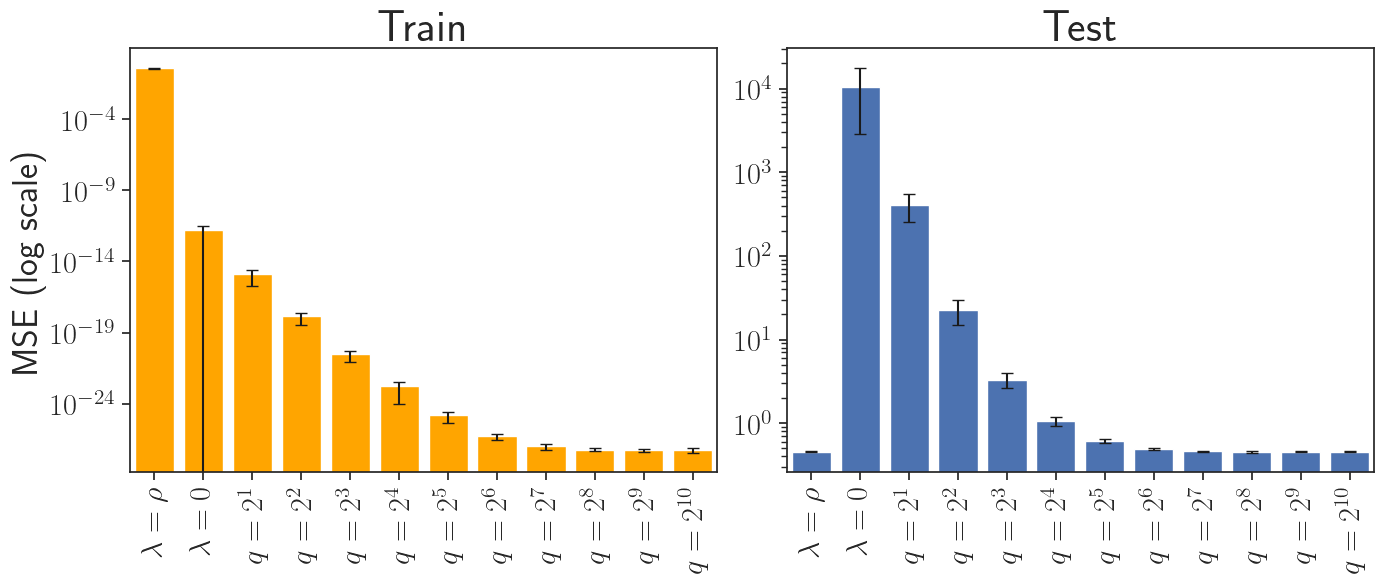

In [23]:
plot_experimentD(
    df_results_calhousing500,
    save_path="calhousingn500.pdf",
    test_decimal_ticks=False
)

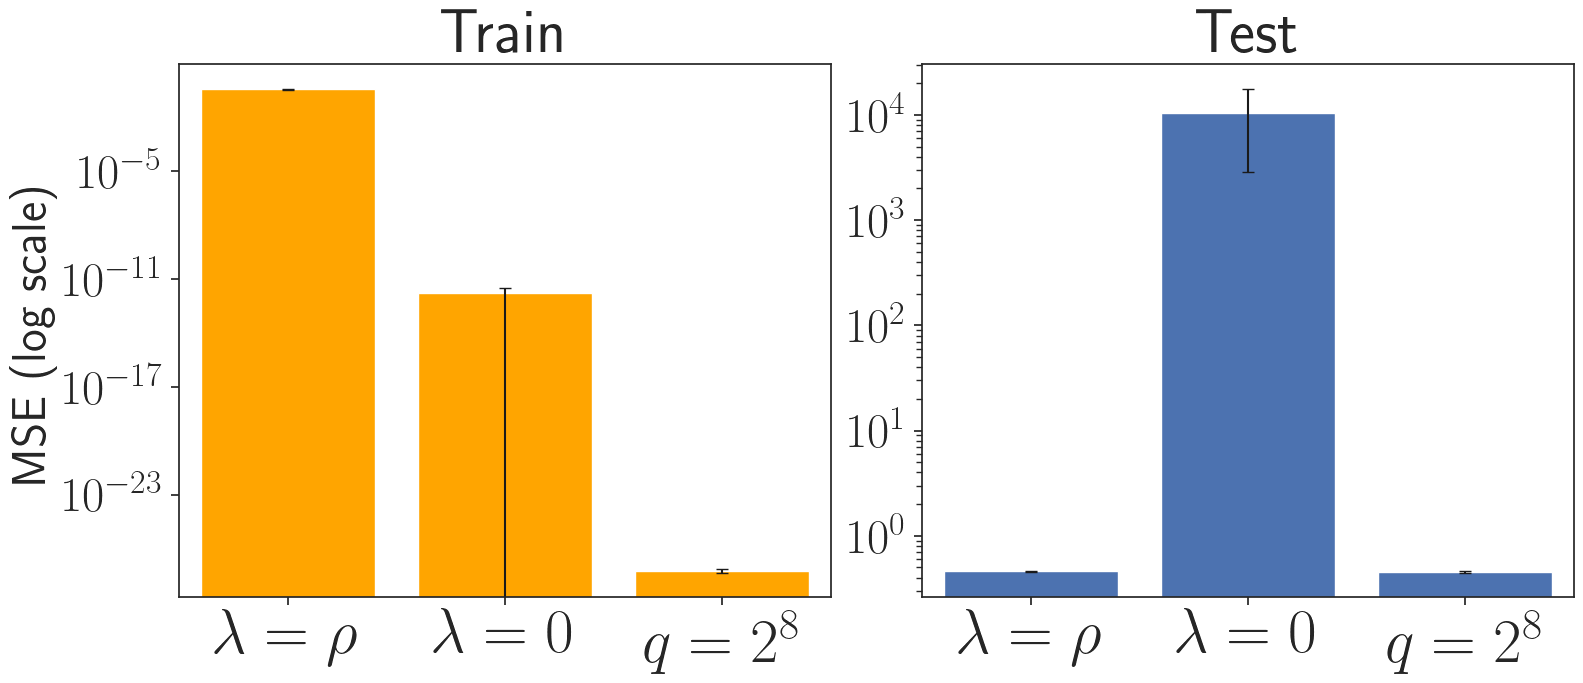

Best q selected: 256


In [24]:
title_fontsize=40+5
label_fontsize=30 +5
tick_fontsize=40+5
figsize=(16, 7)
ytick_label_fontsize=30+5
plot_experimentD_bestq(
    df_results_calhousing500,
    save_path="calhousingn500_bestq.pdf",
    title_fontsize=title_fontsize,
    label_fontsize=label_fontsize,
    tick_fontsize=tick_fontsize,
    figsize=figsize,
    ytick_label_fontsize=ytick_label_fontsize,
    test_decimal_ticks=False
)